In [1]:
import re
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from venny4py.venny4py import *
from Bio import SeqIO, Entrez
import py3Dmol

from dotenv import load_dotenv
env_file = '/home/yuan/bio/bio_omics/src/.env'
load_dotenv(dotenv_path = env_file)

True

In [6]:
%load_ext autoreload
%autoreload 2
    
src_dir = os.path.dirname(os.getcwd())
print('src direcotry is ', src_dir)
bioomics_dir = '/home/yuan/bio/bio_omics/src'
for _dir in (src_dir, bioomics_dir):
    if _dir not in sys.path:
        sys.path.append(_dir)
print(sys.path)

from bioomics import QueryComplex
from plot_clinic import PlotClinic
from layout import Layout

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
src direcotry is  /home/yuan/bio/predict_antibody
['/home/yuan/bio/anaconda3/envs/simulate2/lib/python312.zip', '/home/yuan/bio/anaconda3/envs/simulate2/lib/python3.12', '/home/yuan/bio/anaconda3/envs/simulate2/lib/python3.12/lib-dynload', '', '/home/yuan/bio/anaconda3/envs/simulate2/lib/python3.12/site-packages', '/home/yuan/bio/predict_antibody', '/home/yuan/bio/bio_omics/src']


## FDA IND

In [8]:
output_dir = '/home/yuan/output/clinical_trials'
infile = os.path.join(output_dir, 'clinical_trials.csv')
df = pd.read_csv(infile)

mabs = df[df['official_title'].str.lower().str.contains('monoclonal antibody', na=False)]
print(mabs.shape)

(694, 7)


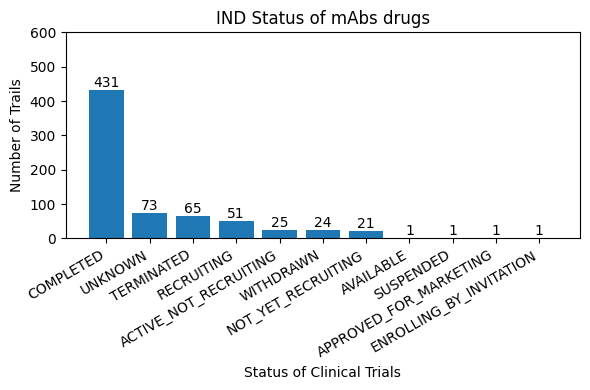

In [5]:
status = mabs['overall_status'].value_counts()
status = status.sort_values(ascending=False)

fig, ax = plt.subplots(1, figsize=(6,4), layout='tight')
ax.set_title('IND Status of mAbs drugs')
bars = ax.bar(status.index, status)
ax.bar_label(bars, label_type='edge')
ax.set_xlabel('Status of Clinical Trials')
ax.set_xticks(range(len(status)))
ax.set_xticklabels(status.index, rotation=30, ha='right')
ax.set_ylabel('Number of Trails')
ax.set_ylim(0, 600)
plt.show()

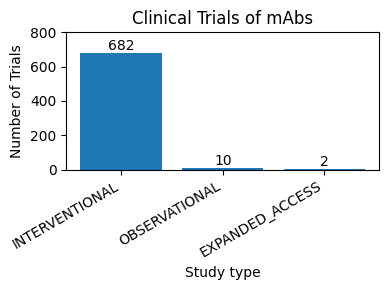

In [9]:
fig, ax = plt.subplots(1, figsize=(4,3), layout='tight')

types = mabs['study_type'].value_counts()
bars = ax.bar(types.index, types)
ax.bar_label(bars)
ax.set_xlabel('Study type')
ax.set_xticks(range(len(types)))
ax.set_xticklabels(types.index, rotation=30, ha='right')
ax.set_ylabel('Number of Trials')
ax.set_ylim(0, 800)
ax.set_title('Clinical Trials of mAbs')
plt.show()

figure size: 11.4 x 6 cm
[np.float64(3.2), np.float64(3.3), np.float64(3.4)]


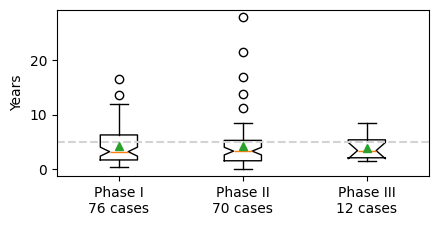

In [35]:
from dateutil.parser import parse

args = {'width_level': 2, 'height': 6}
fig, ax = Layout(args).one()

def phase_duration(x):
    start = parse(x['start_date'], fuzzy=True)
    last = parse(x['completion_date'], fuzzy=True)
    d = round((last - start).days/365, 1)
    return d
    
phases = []
for name in ('phase i ', 'phase ii ', 'phase iii '):
    phase1 = mabs[mabs['official_title'].str.lower().str.contains(name)]
    phase1 = phase1[phase1['start_date'].notna() & phase1['completion_date'].notna()]
    phase1 = phase1.apply(phase_duration, axis=1)
    phases.append(phase1)
m = [np.median(i) for i in phases]
print(m)

#Duration of Completed Clinical Trials of mAbs
labels = ['Phase I', 'Phase II', 'Phase III']
labels = [f"{a}\n{len(b)} cases" for a,b in zip(labels, phases)]
ax.boxplot(phases, notch=True, showmeans=True, tick_labels=labels)
ax.set_ylabel('Years')
ax.axhline(5, linestyle='--', color='lightgrey')
plt.show()

fig.savefig('../figures/clinic_trials_years.tif', dpi=300, bbox_inches='tight', pad_inches=.05)

[np.float64(3.2), np.float64(3.3), np.float64(3.4)]